In [ ]:
# Consumer Behavior Segmentation & Customer Loyalty Analysis Using K-Means

## Objective
To segment customers into meaningful groups based on their demographic characteristics, spending behavior, loyalty status, and satisfaction levels using K-Means clustering.

In [ ]:
## Project Workflow

1. Load and understand the dataset
2. Check data quality and missing values
3. Select relevant features
4. Encode categorical variables
5. Standardize numerical features
6. Determine the optimal number of clusters
7. Apply K-Means clustering
8. Profile and interpret customer segments
9. Generate business insights

In [70]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Libraries imported Successfully!")

Libraries imported Successfully!


In [67]:
df= pd.read_excel("synthetic_consumer_behavior_10000.xlsx")

print('Dataset loaded successfully')
print("shape:",df.shape)

Dataset loaded successfully
shape: (10000, 10)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         10000 non-null  object 
 1   Age                 10000 non-null  int64  
 2   Gender              10000 non-null  object 
 3   Income_Level        10000 non-null  object 
 4   Region              10000 non-null  object 
 5   Purchase_Category   10000 non-null  object 
 6   Avg_Spend           10000 non-null  float64
 7   Payment_Mode        10000 non-null  object 
 8   Loyalty_Member      10000 non-null  object 
 9   Satisfaction_Score  10000 non-null  float64
dtypes: float64(2), int64(1), object(7)
memory usage: 781.4+ KB


In [13]:
df.head()

,Customer_ID,Age,Gender,Income_Level,Region,Purchase_Category,Avg_Spend,Payment_Mode,Loyalty_Member,Satisfaction_Score
0,C00001,56,F,High,Urban,Apparel,97.67,UPI,No,1.4
1,C00002,69,M,Medium,Rural,Apparel,178.48,Wallet,Yes,2.6
2,C00003,46,M,Medium,Semi-Urban,Electronics,257.48,Credit Card,Yes,2.7
3,C00004,32,F,Low,Semi-Urban,Electronics,114.13,Credit Card,Yes,3.7
4,C00005,60,M,Medium,Rural,Home & Kitchen,109.93,Cash,No,3.6


In [14]:
df.describe(include="all")

,Customer_ID,Age,Gender,Income_Level,Region,Purchase_Category,Avg_Spend,Payment_Mode,Loyalty_Member,Satisfaction_Score
count,10000,10000.000000,10000,10000,10000,10000,10000.000000,10000,10000,10000.000000
unique,10000,NaN,3,3,3,6,NaN,5,2,NaN
top,C09984,NaN,M,Medium,Urban,Health & Beauty,NaN,Credit Card,Yes,NaN
freq,1,NaN,4875,5145,5027,1716,NaN,2076,5982,NaN
mean,NaN,43.539400,NaN,NaN,NaN,NaN,200.986765,NaN,NaN,3.003250
std,NaN,14.911636,NaN,NaN,NaN,NaN,97.178486,NaN,NaN,1.150721
min,NaN,18.000000,NaN,NaN,NaN,NaN,10.000000,NaN,NaN,1.000000
25%,NaN,31.000000,NaN,NaN,NaN,NaN,131.065000,NaN,NaN,2.000000
50%,NaN,43.000000,NaN,NaN,NaN,NaN,199.415000,NaN,NaN,3.000000
75%,NaN,56.000000,NaN,NaN,NaN,NaN,267.752500,NaN,NaN,4.000000


In [15]:
df.isnull().sum()

Customer_ID           0
Age                   0
Gender                0
Income_Level          0
Region                0
Purchase_Category     0
Avg_Spend             0
Payment_Mode          0
Loyalty_Member        0
Satisfaction_Score    0
dtype: int64

In [17]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [19]:
df.dtypes

Customer_ID            object
Age                     int64
Gender                 object
Income_Level           object
Region                 object
Purchase_Category      object
Avg_Spend             float64
Payment_Mode           object
Loyalty_Member         object
Satisfaction_Score    float64
dtype: object

In [20]:
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].unique())


Customer_ID:
['C00001' 'C00002' 'C00003' ... 'C09998' 'C09999' 'C10000']

Age:
[56 69 46 32 60 25 38 36 40 28 41 53 57 20 39 19 61 47 55 50 29 42 66 44
 59 45 33 64 68 54 24 26 35 21 31 67 43 37 52 34 23 51 27 48 65 62 58 18
 22 30 49 63]

Gender:
['F' 'M' 'Other']

Income_Level:
['High' 'Medium' 'Low']

Region:
['Urban' 'Rural' 'Semi-Urban']

Purchase_Category:
['Apparel' 'Electronics' 'Home & Kitchen' 'Health & Beauty'
 'Sports & Fitness' 'Groceries']

Avg_Spend:
[ 97.67 178.48 257.48 ... 354.56 198.97 363.03]

Payment_Mode:
['UPI' 'Wallet' 'Credit Card' 'Cash' 'Debit Card']

Loyalty_Member:
['No' 'Yes']

Satisfaction_Score:
[1.4 2.6 2.7 3.7 3.6 3.2 1.1 1.6 4.6 4.2 1.7 4.4 1.8 3.9 1.2 3.4 2.  3.
 2.5 2.2 4.8 3.3 4.5 4.  4.7 4.3 1.9 3.5 1.5 3.1 4.1 2.9 2.3 5.  2.8 3.8
 2.1 1.3 2.4 1.  4.9]


In [21]:
model_df = df[
    [
        "Customer_ID",
        "Age",
        "Income_Level",
        "Avg_Spend",
        "Loyalty_Member",
        "Satisfaction_Score"
    ]
].copy()

model_df.head()


,Customer_ID,Age,Income_Level,Avg_Spend,Loyalty_Member,Satisfaction_Score
0,C00001,56,High,97.67,No,1.4
1,C00002,69,Medium,178.48,Yes,2.6
2,C00003,46,Medium,257.48,Yes,2.7
3,C00004,32,Low,114.13,Yes,3.7
4,C00005,60,Medium,109.93,No,3.6


In [25]:
model_df.shape

(10000, 6)

In [34]:
model_df[["Age","Avg_Spend","Satisfaction_Score"]].describe()


,Age,Avg_Spend,Satisfaction_Score
count,10000.000000,10000.000000,10000.000000
mean,43.539400,200.986765,3.003250
std,14.911636,97.178486,1.150721
min,18.000000,10.000000,1.000000
25%,31.000000,131.065000,2.000000
50%,43.000000,199.415000,3.000000
75%,56.000000,267.752500,4.000000
max,69.000000,629.890000,5.000000


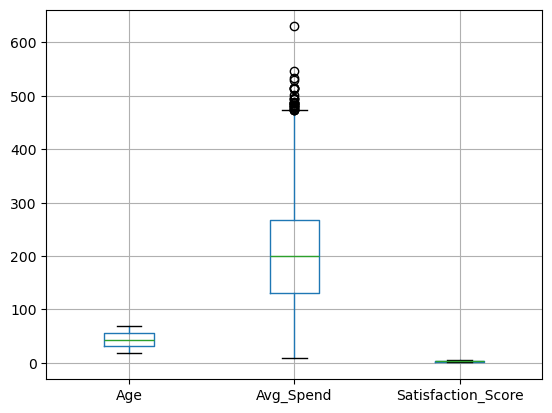

In [36]:
model_df[["Age","Avg_Spend","Satisfaction_Score"]].boxplot()
plt.show()

In [42]:
model_df["Income_Level"] = model_df["Income_Level"].map({
    "Low":1,
    "Medium ": 2,
    "High" : 3
})

model_df["Loyalty_Member"] = model_df["Loyalty_Member"].map({
    "Yes":1,
    "No": 0
})

model_df.head()
    

,Customer_ID,Age,Income_Level,Avg_Spend,Loyalty_Member,Satisfaction_Score
0,C00001,56,3.0,97.67,0,1.4
1,C00002,69,NaN,178.48,1,2.6
2,C00003,46,NaN,257.48,1,2.7
3,C00004,32,1.0,114.13,1,3.7
4,C00005,60,NaN,109.93,0,3.6


In [51]:
features=[
    'Age',
    'Income_Level',
    'Avg_Spend',
    'Loyalty_Member',
    'Satisfaction_Score'
]
scaler= StandardScaler()
X = scaler.fit_transform(model_df[features])

print("standardization is completed successfully")




standardization is completed successfully


In [54]:
X= scaler.fit_transform(model_df[features])

print("X created ")


X created 


In [56]:
print (model_df[features].isnull().sum())

Age                      0
Income_Level          5145
Avg_Spend                0
Loyalty_Member           0
Satisfaction_Score       0
dtype: int64


In [57]:
print (df["Income_Level"].value_counts())

Income_Level
Medium    5145
Low       2852
High      2003
Name: count, dtype: int64


In [59]:
model_df = df[
    [
        "Customer_ID",
        "Age",
        "Income_Level",
        "Avg_Spend",
        "Loyalty_Member",
        "Satisfaction_Score"
    ]
].copy()

In [60]:
model_df["Income_Level"] = model_df["Income_Level"].map({
    "Low": 1,
    "Medium": 2,
    "High": 3
})

model_df["Loyalty_Member"] = model_df["Loyalty_Member"].map({
    "No": 0,
    "Yes": 1
})

In [61]:
print(model_df[features].isnull().sum())



Age                   0
Income_Level          0
Avg_Spend             0
Loyalty_Member        0
Satisfaction_Score    0
dtype: int64


In [63]:
scaler = StandardScaler()

X = scaler.fit_transform(model_df[features])

print("X recreated successfully!")

X recreated successfully!


In [72]:

inertia = []



for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

print(inertia)

[39994.363996117805, 35536.97634687056, 32219.78893628463, 29559.4427543888, 27471.503726318428, 25590.88214196941, 23694.784028821043, 22553.97798267303, 21242.58278417326]


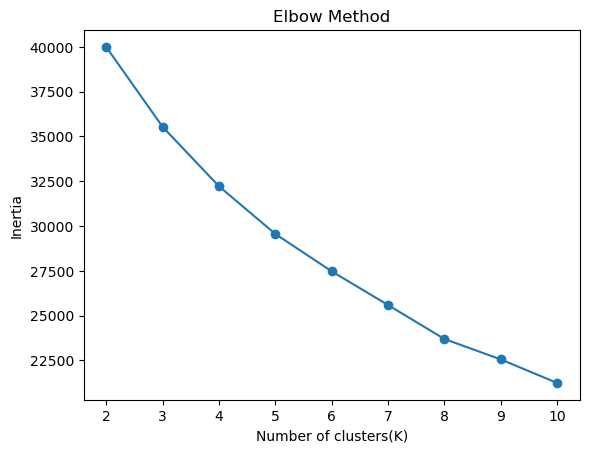

In [73]:
plt.plot(range(2,11),inertia,marker="o")
plt.xlabel("Number of clusters(K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [75]:
from sklearn.metrics import silhouette_score

In [83]:
silhouette_scores=[]

for k in range(2,11):
    kmeans= KMeans(n_clusters=k, random_state=42,n_init=10)
    labels= kmeans.fit_predict(X)
    score = silhouette_score(X,labels)
    silhouette_scores.append(score)

print(silhouette_score)    


<function silhouette_score at 0x00000186B6DE6A20>


In [85]:
print(silhouette_scores)

[np.float64(0.2175887601866254), np.float64(0.17779044624984686), np.float64(0.17866935016094343), np.float64(0.18666711529135588), np.float64(0.17647474672128968), np.float64(0.1795829004312102), np.float64(0.1953740067246012), np.float64(0.19403166258437304), np.float64(0.196284869970754)]


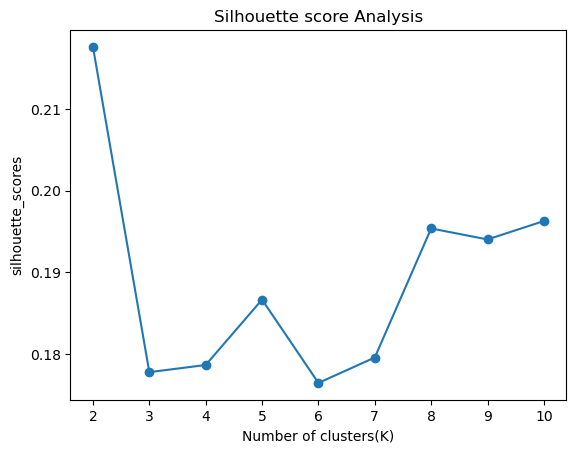

In [87]:
plt.plot(range(2,11),silhouette_scores,marker='o')
plt.xlabel("Number of clusters(K)")
plt.ylabel("silhouette_scores")
plt.title("Silhouette score Analysis")
plt.show()
         

In [88]:
kmeans=KMeans (n_clusters=k,random_state=42,n_init=10)
model_df["cluster"] = kmeans.fit_predict(X)

print("Final clustering completed")

Final clustering completed


In [90]:
model_df["cluster"].value_counts().sort_index()


cluster
0    1000
1    1263
2    1005
3     857
4     799
5     962
6     958
7     976
8    1053
9    1127
Name: count, dtype: int64

In [92]:
print(kmeans.n_clusters)
print(model_df["cluster"].nunique())


10
10


In [93]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

model_df["cluster"] = kmeans.fit_predict(X)

print(model_df["cluster"].nunique())


5


In [95]:

model_df["cluster"].value_counts().sort_index()


cluster
0    2098
1    2020
2    1707
3    1998
4    2177
Name: count, dtype: int64

In [96]:
cluster_profile = model_df.groupby("cluster")[
    ["Age", "Income_Level", "Avg_Spend", "Loyalty_Member", "Satisfaction_Score"]
].mean()

print(cluster_profile)

               Age  Income_Level   Avg_Spend  Loyalty_Member  \
cluster                                                        
0        43.369399      2.264538  202.991730             1.0   
1        42.932178      1.906931  201.865812             0.0   
2        43.613943      1.000000  202.829303             1.0   
3        43.663163      1.934935  197.089910             0.0   
4        44.094626      2.285255  200.370602             1.0   

         Satisfaction_Score  
cluster                      
0                  2.004290  
1                  3.988515  
2                  3.015700  
3                  1.969419  
4                  3.990813  


In [98]:
cluster_categories = df.copy()
cluster_categories["cluster"] = model_df["cluster"]

print(
    cluster_categories.groupby("cluster")[
        ["Gender", "Region", "Purchase_Category", "Payment_Mode"]
    ].agg(lambda x: x.mode()[0])
)

        Gender Region Purchase_Category Payment_Mode
cluster                                             
0            F  Urban  Sports & Fitness  Credit Card
1            M  Urban       Electronics       Wallet
2            F  Urban           Apparel   Debit Card
3            M  Urban       Electronics       Wallet
4            M  Urban   Health & Beauty  Credit Card


In [99]:
print(
    cluster_categories.groupby("cluster")[
        ["Gender", "Region", "Purchase_Category", "Payment_Mode"]
    ].agg(lambda x: x.mode()[0])
)

        Gender Region Purchase_Category Payment_Mode
cluster                                             
0            F  Urban  Sports & Fitness  Credit Card
1            M  Urban       Electronics       Wallet
2            F  Urban           Apparel   Debit Card
3            M  Urban       Electronics       Wallet
4            M  Urban   Health & Beauty  Credit Card


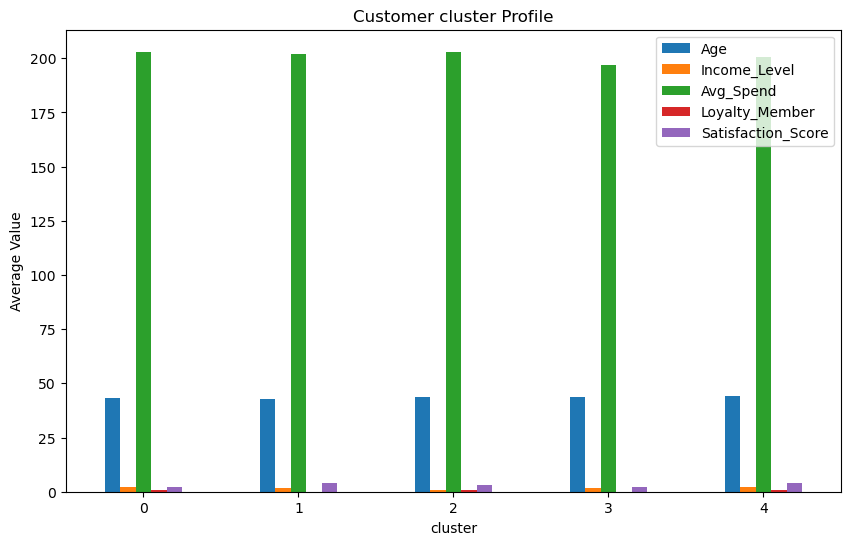

In [100]:
cluster_profile.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Customer cluster Profile")
plt.xlabel("cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend()
plt.show()

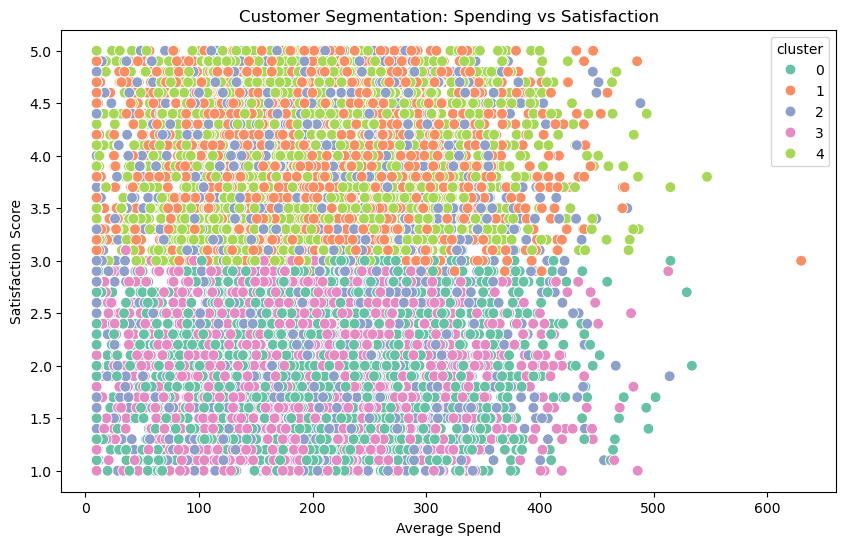

In [101]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=model_df,
    x="Avg_Spend",
    y="Satisfaction_Score",
    hue="cluster",
    palette="Set2",
    s=60
)

plt.title("Customer Segmentation: Spending vs Satisfaction")
plt.xlabel("Average Spend")
plt.ylabel("Satisfaction Score")
plt.legend(title="cluster")
plt.show()

In [102]:
final_profile = model_df.groupby("cluster").agg({
    "Age": "mean",
    "Income_Level": "mean",
    "Avg_Spend": "mean",
    "Loyalty_Member": "mean",
    "Satisfaction_Score": "mean"
}).round(2)

print(final_profile)

           Age  Income_Level  Avg_Spend  Loyalty_Member  Satisfaction_Score
cluster                                                                    
0        43.37          2.26     202.99             1.0                2.00
1        42.93          1.91     201.87             0.0                3.99
2        43.61          1.00     202.83             1.0                3.02
3        43.66          1.93     197.09             0.0                1.97
4        44.09          2.29     200.37             1.0                3.99


In [103]:
cluster_names = {
    0: "Loyal but Dissatisfied Customers",
    1: "Satisfied Non-Loyal Customers",
    2: "Budget-Conscious Loyal Customers",
    3: "At-Risk Customers",
    4: "High-Value Loyal Customers"
}

model_df["Segment_Name"] = model_df["cluster"].map(cluster_names)

print(model_df[["cluster", "Segment_Name"]].drop_duplicates().sort_values("cluster"))

    cluster                      Segment_Name
1         0  Loyal but Dissatisfied Customers
4         1     Satisfied Non-Loyal Customers
3         2  Budget-Conscious Loyal Customers
0         3                 At-Risk Customers
10        4        High-Value Loyal Customers


In [104]:
business_summary = model_df.groupby(
    ["cluster", "Segment_Name"]
).agg(
    Customers=("Customer_ID", "count"),
    Avg_Age=("Age", "mean"),
    Avg_Spend=("Avg_Spend", "mean"),
    Avg_Satisfaction=("Satisfaction_Score", "mean"),
    Loyalty_Rate=("Loyalty_Member", "mean")
).round(2)

print(business_summary)

                                          Customers  Avg_Age  Avg_Spend  \
cluster Segment_Name                                                      
0       Loyal but Dissatisfied Customers       2098    43.37     202.99   
1       Satisfied Non-Loyal Customers          2020    42.93     201.87   
2       Budget-Conscious Loyal Customers       1707    43.61     202.83   
3       At-Risk Customers                      1998    43.66     197.09   
4       High-Value Loyal Customers             2177    44.09     200.37   

                                          Avg_Satisfaction  Loyalty_Rate  
cluster Segment_Name                                                      
0       Loyal but Dissatisfied Customers              2.00           1.0  
1       Satisfied Non-Loyal Customers                 3.99           0.0  
2       Budget-Conscious Loyal Customers              3.02           1.0  
3       At-Risk Customers                             1.97           0.0  
4       High-Value Loyal

In [ ]:
## Business Insights

- Customer segmentation identified five distinct customer groups based on age, income level, average spending, loyalty membership, and satisfaction.
- Cluster 0 represents loyal customers with relatively higher income but low satisfaction.
- Cluster 1 consists of highly satisfied customers who are not currently loyalty members.
- Cluster 2 represents lower-income customers who remain loyal to the business.
- Cluster 3 contains non-loyal customers with low satisfaction and the lowest average spending.
- Cluster 4 represents higher-income, loyal customers with high satisfaction.
- Average spending is relatively similar across all clusters, suggesting that loyalty, income level, and satisfaction contribute more to the segmentation in this dataset.

## Conclusion

K-Means clustering helped divide customers into meaningful behavioral segments. These segments can help businesses understand different customer groups and design more targeted strategies for improving satisfaction, strengthening loyalty, and retaining at-risk customers.